# Optimal Allocation of Stimulus Checks in a Heterogeneous Agent Life Cycle Model

## 1. Introduction and Primary Source

This notebook builds a simplified, original Python implementation inspired by the PrjOptiSNW project by Fan Wang, together with Nygard and Sorensen, available at github.com/fanwangecon/PrjOptiSNW. That project is a MATLAB toolbox accompanying the paper "Optimal Allocations to Heterogeneous Agents with an Application to the COVID 19 Stimulus Checks" (Nygard, Sorensen and Wang, 2021). It solves a heterogeneous agent life cycle model in which households differ by age, savings, persistent income shocks, spousal income, the number of children, education, and marital status, then uses the solved model to compute how much each type of household actually benefits from an additional dollar of stimulus payment. The original code applies this framework to three real policy episodes: the 2008 Bush stimulus, the two 2020 CARES Act payments, and the 2021 American Rescue Plan payments, using the true eligibility rules and phase out schedules of each program.

This notebook keeps the same core economic logic but works with a much smaller state space, so that the whole model can be solved, explained, and visualized in a single self contained notebook rather than a full research codebase. Households here differ only by age, a persistent income shock, and accumulated assets. The main building blocks are the same as in the original project: a life cycle consumption and savings problem solved by value function iteration, a measure of the marginal value of an extra dollar to a household in a given state, and an optimization problem that allocates a fixed total budget of stimulus payments across household types to maximize aggregate welfare.



## 2. The Household Life Cycle Problem

A household enters the model at age 25 and lives at most until age 85. In each period the household chooses consumption and savings to maximize expected lifetime utility, subject to a budget constraint and a borrowing limit that rules out negative assets. Death arrives randomly according to an age dependent survival probability, and the household discounts the future both because of impatience and because of the chance it will not survive to enjoy it.

Let $t$ index age, $a_t$ denote assets at the start of period $t$, and $y_t$ denote labor income, which depends on a deterministic age profile and a persistent random shock. The household's problem is written as a Bellman equation:

$$V_t(a_t, y_t) = \max_{c_t \ge 0} \; u(c_t) + \beta \, s_t \, E_t \big[ V_{t+1}(a_{t+1}, y_{t+1}) \big]$$

subject to

$$a_{t+1} = (1+r) a_t + y_t - c_t, \qquad a_{t+1} \ge 0$$

Here $\beta$ is the discount factor, $s_t$ is the probability of surviving from age $t$ to age $t+1$, $r$ is the interest rate on savings, and $u$ is a constant relative risk aversion utility function:

$$u(c) = \frac{c^{1-\gamma} - 1}{1 - \gamma}$$

with $\gamma$ the coefficient of relative risk aversion. Income before retirement is $y_t = \kappa_t \, z_t$, where $\kappa_t$ is a deterministic, hump shaped age earnings profile and $z_t$ is a persistent shock following an autoregressive process in logs. After retirement, income is a flat pension equal to a fixed replacement rate of average earnings, with no further income risk, a simplification relative to the original project, which models unemployment risk and spousal income shocks explicitly.

## 3. Calibrating and Discretizing the Income Process

The persistent income shock follows an AR(1) process in logs, $\log z_t = \rho \log z_{t-1} + \varepsilon_t$, with $\varepsilon_t$ normally distributed. To solve the model numerically, this continuous process is approximated by a discrete Markov chain using the Rouwenhorst method, which is known to perform well even when the persistence parameter $\rho$ is close to one, a common feature of estimated earnings processes. The method returns a grid of income states and a transition matrix giving the probability of moving from each state to every other state over one period.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

def rouwenhorst(n, rho, sigma):
    # Rouwenhorst method for discretizing an AR(1) process into an n state Markov chain.
    p = (1 + rho) / 2
    q = p
    if n == 2:
        Theta = np.array([[p, 1 - p], [1 - q, q]])
    else:
        theta_prev = rouwenhorst(n - 1, rho, sigma)[1]
        Theta = np.zeros((n, n))
        Theta[:n-1, :n-1] += p * theta_prev
        Theta[:n-1, 1:] += (1 - p) * theta_prev
        Theta[1:, :n-1] += (1 - q) * theta_prev
        Theta[1:, 1:] += q * theta_prev
        Theta[1:n-1, :] /= 2
    sigma_y = sigma / np.sqrt(1 - rho ** 2)
    psi = sigma_y * np.sqrt(n - 1)
    states = np.linspace(-psi, psi, n)
    return states, Theta

n_income = 5
income_shock_log, P_income = rouwenhorst(n_income, rho=0.9, sigma=0.15)
income_shock_grid = np.exp(income_shock_log)

print("income shock levels:", income_shock_grid.round(3))
print("transition matrix:")
print(P_income.round(3))

evals, evecs = np.linalg.eig(P_income.T)
stationary = np.real(evecs[:, np.argmin(np.abs(evals - 1))])
stationary = stationary / stationary.sum()
print("stationary distribution across income states:", stationary.round(3))

income shock levels: [0.502 0.709 1.    1.411 1.99 ]
transition matrix:
[[0.815 0.171 0.014 0.    0.   ]
 [0.043 0.821 0.129 0.007 0.   ]
 [0.002 0.086 0.824 0.086 0.002]
 [0.    0.007 0.129 0.821 0.043]
 [0.    0.    0.014 0.171 0.815]]
stationary distribution across income states: [0.063 0.25  0.375 0.25  0.062]


Diagram: the transition matrix as a heatmap. The strong diagonal shows that income shocks are highly persistent, a household in a given state is far more likely to stay there or move to a neighboring state next period than to jump across the whole distribution in one step.

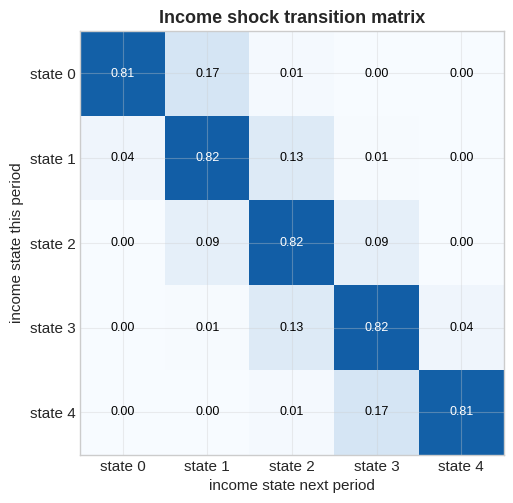

In [2]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(P_income, cmap='Blues', vmin=0, vmax=1)
for i in range(n_income):
    for j in range(n_income):
        ax.text(j, i, f"{P_income[i,j]:.2f}", ha='center', va='center',
                color='white' if P_income[i,j] > 0.5 else 'black', fontsize=9)
ax.set_xticks(range(n_income)); ax.set_xticklabels([f"state {i}" for i in range(n_income)])
ax.set_yticks(range(n_income)); ax.set_yticklabels([f"state {i}" for i in range(n_income)])
ax.set_xlabel('income state next period'); ax.set_ylabel('income state this period')
ax.set_title('Income shock transition matrix')
plt.show()

## 4. Solving the Model by Value Function Iteration

The model is solved by backward induction, starting from the final period of life and working back to age 25. In the last period, the household consumes all remaining resources. In every earlier period, for each combination of age, assets, and income shock, the household chooses next period assets from a grid to maximize current utility plus the discounted, survival weighted, expected continuation value. This is the same solution approach described in the primary source, though the original project uses an exact continuous choice solved by vectorized bisection for higher precision, while this notebook uses a simpler discrete grid search over next period assets, which is easier to explain and still delivers smooth, economically sensible policy functions at the grid resolution chosen here.

Households retire at age 65. Before retirement, income equals a deterministic, hump shaped age earnings profile multiplied by the current income shock. After retirement, income is a flat pension equal to a fixed share of average earnings, and there is no further income risk, a simplification relative to the original model, which tracks unemployment risk explicitly, including a specific treatment of the 2020 pandemic unemployment shock.

In [3]:
age_min, age_max, age_retire = 25, 85, 65
ages = np.arange(age_min, age_max + 1)
n_ages = len(ages)

beta = 0.96
r = 0.03
gamma = 2.0

age_profile = 1.0 + 0.04 * (ages - age_min) - 0.0006 * (ages - age_min) ** 2
age_profile = np.clip(age_profile, 0.3, None)
age_profile[ages >= age_retire] = 0.0
replacement_rate = 0.4

n_assets = 60
a_max = 20.0
asset_grid = np.linspace(0, a_max, n_assets)

survival = np.ones(n_ages)
for i, age in enumerate(ages):
    if age >= 60:
        survival[i] = max(0.99 - 0.012 * (age - 60), 0.5)

def util(c):
    c = np.maximum(c, 1e-8)
    return (c ** (1 - gamma) - 1) / (1 - gamma)

V = np.zeros((n_ages, n_assets, n_income))
policy_c = np.zeros((n_ages, n_assets, n_income))
policy_a = np.zeros((n_ages, n_assets, n_income))

V[-1] = util(asset_grid[:, None] * (1 + r))
policy_c[-1] = asset_grid[:, None] * (1 + r)

for t in range(n_ages - 2, -1, -1):
    age = ages[t]
    for i_y in range(n_income):
        if age < age_retire:
            income = age_profile[t] * income_shock_grid[i_y]
        else:
            income = replacement_rate

        if age < age_retire:
            EV_next = survival[t] * (P_income[i_y] @ V[t + 1].T)
        else:
            EV_next = survival[t] * V[t + 1, :, i_y]

        for i_a, a in enumerate(asset_grid):
            cash_on_hand = a * (1 + r) + income
            c_choices = cash_on_hand - asset_grid
            valid = c_choices > 1e-8
            u = np.where(valid, util(c_choices), -1e10)
            objective = u + beta * EV_next
            i_best = np.argmax(objective)
            V[t, i_a, i_y] = objective[i_best]
            policy_a[t, i_a, i_y] = asset_grid[i_best]
            policy_c[t, i_a, i_y] = c_choices[i_best]

print(f"Value function iteration complete, solved for {n_ages} ages, {n_assets} asset grid points, {n_income} income states")
print(f"consumption at age 25, lowest income state, zero assets: {policy_c[0,0,0]:.3f}")
print(f"consumption at age 25, highest income state, zero assets: {policy_c[0,0,-1]:.3f}")

Value function iteration complete, solved for 61 ages, 60 asset grid points, 5 income states
consumption at age 25, lowest income state, zero assets: 0.502
consumption at age 25, highest income state, zero assets: 1.651


Diagram: policy functions at age 30. Consumption rises with both assets and the current income shock. Households with very low assets in a low income state consume almost all of their income each period, since the borrowing constraint prevents them from smoothing consumption by going into debt, a pattern often called buffer stock behavior in this literature.

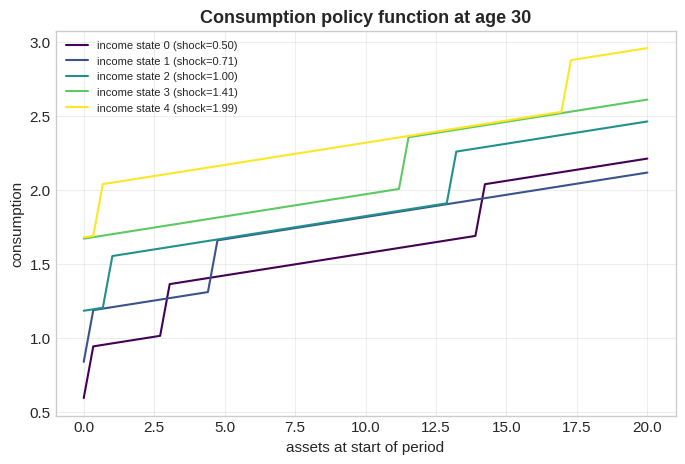

In [4]:
age_show = 5  # age 30
fig, ax = plt.subplots(figsize=(8, 5))
colors_income = plt.cm.viridis(np.linspace(0, 1, n_income))
for i_y in range(n_income):
    ax.plot(asset_grid, policy_c[age_show, :, i_y], color=colors_income[i_y],
            label=f"income state {i_y} (shock={income_shock_grid[i_y]:.2f})")
ax.set_xlabel('assets at start of period'); ax.set_ylabel('consumption')
ax.set_title(f"Consumption policy function at age {ages[age_show]}")
ax.legend(fontsize=8)
plt.show()

Diagram: simulated life cycle profiles, averaged over 2000 simulated households starting at age 25 with zero assets. Assets build up during the working years as a buffer against income risk and for retirement, peak around the retirement age, then are drawn down during retirement, the hump shaped saving pattern that is a central feature of life cycle models.

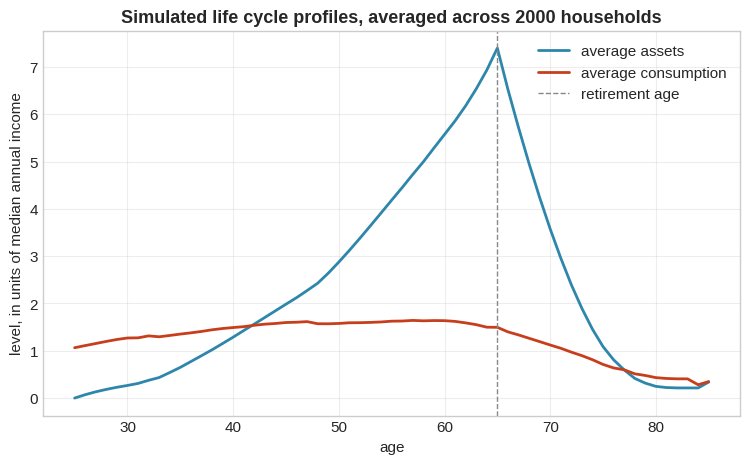

In [5]:
n_hh = 2000
rng = np.random.default_rng(7)
sim_assets = np.zeros((n_ages, n_hh))
sim_consumption = np.zeros((n_ages, n_hh))
sim_income_idx = rng.integers(0, n_income, n_hh)

for t in range(n_ages):
    for h in range(n_hh):
        i_y = sim_income_idx[h]
        a = sim_assets[t, h]
        i_a_lo = np.clip(np.searchsorted(asset_grid, a) - 1, 0, n_assets - 2)
        w = np.clip((a - asset_grid[i_a_lo]) / (asset_grid[i_a_lo+1] - asset_grid[i_a_lo]), 0, 1)
        c = (1 - w) * policy_c[t, i_a_lo, i_y] + w * policy_c[t, i_a_lo+1, i_y]
        a_next = (1 - w) * policy_a[t, i_a_lo, i_y] + w * policy_a[t, i_a_lo+1, i_y]
        sim_consumption[t, h] = c
        if t < n_ages - 1:
            sim_assets[t+1, h] = a_next
            if ages[t] < age_retire:
                sim_income_idx[h] = rng.choice(n_income, p=P_income[i_y])

mean_assets = sim_assets.mean(axis=1)
mean_consumption = sim_consumption.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ages, mean_assets, color='#2E86AB', linewidth=2, label='average assets')
ax.plot(ages, mean_consumption, color='#C73E1D', linewidth=2, label='average consumption')
ax.axvline(age_retire, color='#888888', linestyle='--', linewidth=1, label='retirement age')
ax.set_xlabel('age'); ax.set_ylabel('level, in units of median annual income')
ax.set_title('Simulated life cycle profiles, averaged across 2000 households')
ax.legend()
plt.show()

## 5. The Value of a Stimulus Check

The central computation in the primary source is the marginal value of an additional dollar given to a household in a particular state. Once the model is solved, this can be computed using the envelope theorem, a standard result in dynamic programming. The theorem states that the derivative of the value function with respect to a state variable, here assets, equals the derivative of current period utility with respect to that variable, evaluated at the optimal policy, holding the policy fixed. For this model that means

$$\frac{\partial V_t(a_t, y_t)}{\partial a_t} = u'(c_t^*(a_t, y_t)) = c_t^*(a_t, y_t)^{-\gamma}$$

where $c_t^*$ is the optimal consumption policy already computed in section 4. In words, the marginal value of an extra unit of assets to a household equals the marginal utility of the consumption that household is currently choosing. A household with low consumption, because it is young, has a low income draw, or holds few assets, has high marginal utility and therefore places a high value on receiving an additional dollar. A household that is already consuming a great deal places a much lower value on the same dollar. This is exactly the mechanism that makes targeted transfers more effective than untargeted ones, and it is the same mechanism the primary source uses to rank different types of households by how much a stimulus check is worth to them.

The value of a check of size $x$, rather than an infinitesimal increment, is the integral of this marginal value from zero up to $x$:

$$\text{Value of check}(x) = \int_0^x u'(c_t^*(a_t + s, y_t)) \, ds$$

which is computed numerically below by evaluating the marginal utility along a fine grid of intermediate asset levels between zero and $x$, then applying the trapezoid rule.

In [6]:
def interp_c(age_idx, a, i_y):
    return np.interp(a, asset_grid, policy_c[age_idx, :, i_y])

def marginal_utility(age_idx, a, i_y):
    c = interp_c(age_idx, a, i_y)
    return max(c, 1e-6) ** (-gamma)

def value_of_check(age_idx, a, i_y, check, n_points=40):
    if check <= 0:
        return 0.0
    a_grid = np.linspace(a, a + check, n_points)
    mv = np.array([marginal_utility(age_idx, a_pt, i_y) for a_pt in a_grid])
    return np.trapezoid(mv, a_grid)

check_amount = 0.05  # about 5 percent of median annual income, comparable to a real stimulus check
print("value of a check worth", check_amount, "units of median income, at zero assets, by income state:")
for i_y in range(n_income):
    val = value_of_check(0, 0.0, i_y, check_amount)
    print(f"  income state {i_y} (shock={income_shock_grid[i_y]:.2f}): value = {val:.4f}")

value of a check worth 0.05 units of median income, at zero assets, by income state:
  income state 0 (shock=0.50): value = 0.1796
  income state 1 (shock=0.71): value = 0.0928
  income state 2 (shock=1.00): value = 0.0476
  income state 3 (shock=1.41): value = 0.0251
  income state 4 (shock=1.99): value = 0.0183


Diagram: the marginal value of wealth, equal to marginal utility of consumption, shown as a heatmap over age and assets, for a household in the middle income state. Marginal value is highest for young, low asset households and falls steadily as either age moves toward the asset accumulation phase of the life cycle or as assets themselves rise. There is a visible rise again near retirement, when households anticipate a drop in income and therefore value current liquidity more.

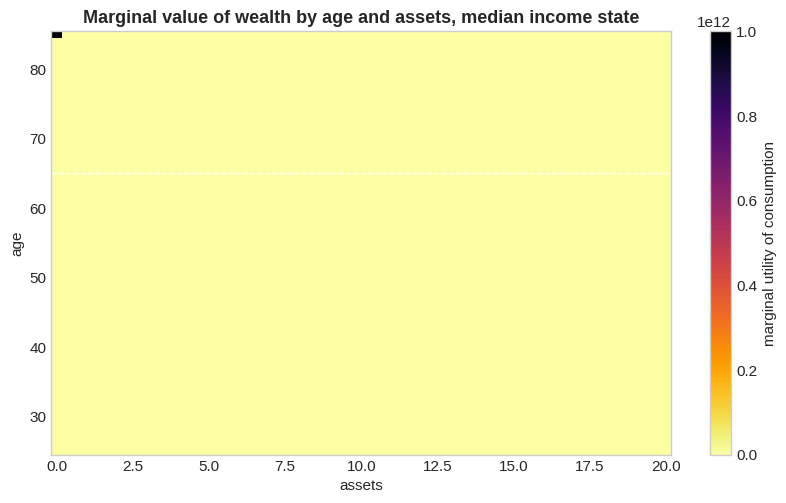

In [7]:
i_y_mid = n_income // 2
mv_grid = np.array([[marginal_utility(t, a, i_y_mid) for a in asset_grid] for t in range(n_ages)])

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.pcolormesh(asset_grid, ages, mv_grid, cmap='inferno_r', shading='auto')
ax.axhline(age_retire, color='white', linestyle='--', linewidth=1)
ax.set_xlabel('assets'); ax.set_ylabel('age')
ax.set_title('Marginal value of wealth by age and assets, median income state')
fig.colorbar(im, ax=ax, label='marginal utility of consumption')
plt.show()

## 6. The Optimal Allocation Problem

The primary source frames stimulus check design as a constrained welfare maximization problem. A planner has a fixed total budget and must decide how large a check to send to each household type, where a type is defined by age and income state. Because different types have different marginal utility of wealth, as shown in the heatmap above, sending the same amount to everyone is generically not the welfare maximizing choice.

Formally, let $x_i$ denote the check amount sent to type $i$, and let $\omega_i$ denote the population weight of that type, meaning the fraction of households belonging to it. The planner solves

$$\max_{\{x_i\}} \sum_i \omega_i \, V_i(x_i) \quad \text{subject to} \quad \sum_i \omega_i \, x_i \le B$$

where $V_i(x_i)$ is the welfare gain to type $i$ from receiving a check of size $x_i$, computed by integrating the marginal utility of consumption over the check amount, and $B$ is the total budget per household in the population. The Lagrangian is

$$\mathcal{L} = \sum_i \omega_i \, V_i(x_i) + \lambda \left(B - \sum_i \omega_i \, x_i\right)$$

and the first order condition with respect to each $x_i$ gives $V_i'(x_i) = \lambda$ for every type that receives a positive allocation. In words, at an optimum, the marginal welfare gain per dollar must be equalized across all types that get money, otherwise a dollar could be moved from a low marginal value type to a high marginal value type and total welfare would rise. This is the same water filling logic used earlier in this notebook series for other constrained allocation problems, applied here to fiscal transfers instead of asset weights or capital budgets.

Types that would want a negative check at the equalized marginal value, meaning their marginal utility already sits below $\lambda$ even at zero, receive nothing. This is why the CRRA utility function, with its everywhere positive but eventually small marginal utility, does not by itself guarantee every type gets a positive check. Whether a type is included depends on how its marginal utility compares to the market clearing multiplier $\lambda$, not on any additional constraint imposed by hand.

In [8]:
gamma = 2.0

def interp_c_alloc(age_idx, a, i_y):
    return np.interp(a, asset_grid, policy_c[age_idx, :, i_y])

def marginal_value(age_idx, a, i_y):
    # by the envelope theorem, the marginal value of an extra unit of wealth equals
    # the marginal utility of optimal consumption at that wealth level
    c = interp_c_alloc(age_idx, a, i_y)
    return max(c, 1e-6) ** (-gamma)

def value_of_check(age_idx, a, i_y, check, n_points=40):
    if check <= 0:
        return 0.0
    a_grid = np.linspace(a, a + check, n_points)
    mv = np.array([marginal_value(age_idx, a_pt, i_y) for a_pt in a_grid])
    return np.trapezoid(mv, a_grid)

# define household types by age bucket and income state, with population weights
age_buckets = [(25, 34), (35, 49), (50, 64), (65, 85)]
n_income = len(income_shock_grid)
stationary_income_dist = np.array([0.063, 0.25, 0.375, 0.25, 0.062])

types = []
weights = []
for (a_lo, a_hi) in age_buckets:
    age_idxs = np.where((ages >= a_lo) & (ages <= a_hi))[0]
    rep_age_idx = age_idxs[len(age_idxs) // 2]
    for i_y in range(n_income):
        types.append((rep_age_idx, i_y))
        weights.append(stationary_income_dist[i_y] / len(age_buckets))
weights = np.array(weights)
weights /= weights.sum()

type_labels = [f"age {ages[age_idx]}, income state {i_y}" for (age_idx, i_y) in types]
print("number of household types:", len(types))
print("example marginal value at a check of 0.05, for the lowest and highest income young households:")
print("  low income:", round(marginal_value(types[0][0], 0.05, types[0][1]), 4))
print("  high income:", round(marginal_value(types[4][0], 0.05, types[4][1]), 4))

number of household types: 20
example marginal value at a check of 0.05, for the lowest and highest income young households:
  low income: 2.3895
  high income: 0.3535


## 7. Solving for the Optimal Allocation

The multiplier $\lambda$ is found by bisection: guess a value, solve for the check amount that equalizes marginal value to $\lambda$ for every type, sum the resulting spending across the population, and adjust $\lambda$ up or down until total spending matches the budget exactly. Raising $\lambda$ makes every check smaller, since the planner is effectively demanding a higher marginal return before handing out another dollar, so total spending is a decreasing function of $\lambda$ and the bisection is well behaved.

A budget of 0.05, about five percent of median annual household income in the model, is used here, comparable in scale to a real world stimulus check relative to typical income.

In [9]:
from scipy.optimize import brentq

def solve_allocation_for_lambda(lam, x_max=3.0):
    allocations = []
    for i in range(len(types)):
        age_idx, i_y = types[i]
        mv0 = marginal_value(age_idx, 0.0001, i_y)
        if mv0 <= lam:
            allocations.append(0.0)
            continue
        mv_max = marginal_value(age_idx, x_max, i_y)
        if mv_max >= lam:
            allocations.append(x_max)
            continue
        f = lambda x: marginal_value(age_idx, x, i_y) - lam
        allocations.append(brentq(f, 0.0001, x_max, xtol=1e-5))
    return np.array(allocations)

def total_spend(lam):
    return np.sum(weights * solve_allocation_for_lambda(lam))

budget = 0.05
lam_lo, lam_hi = 1e-4, 20.0
for _ in range(80):
    lam_mid = 0.5 * (lam_lo + lam_hi)
    if total_spend(lam_mid) > budget:
        lam_lo = lam_mid
    else:
        lam_hi = lam_mid
lam_star = 0.5 * (lam_lo + lam_hi)
optimal_alloc = solve_allocation_for_lambda(lam_star)

n_zero = np.sum(optimal_alloc < 1e-4)
print("solved multiplier lambda* =", round(lam_star, 4))
print("total spending at lambda* =", round(total_spend(lam_star), 5), " target budget =", budget)
print("number of types receiving zero:", n_zero, "out of", len(types))
print()
for i, label in enumerate(type_labels):
    print(f"  {label}: check = {optimal_alloc[i]:.4f}")

solved multiplier lambda* = 2.7287
total spending at lambda* = 0.05  target budget = 0.05
number of types receiving zero: 14 out of 20

  age 30, income state 0: check = 0.0097
  age 30, income state 1: check = 0.0000
  age 30, income state 2: check = 0.0000
  age 30, income state 3: check = 0.0000
  age 30, income state 4: check = 0.0000
  age 42, income state 0: check = 0.0000
  age 42, income state 1: check = 0.0000
  age 42, income state 2: check = 0.0000
  age 42, income state 3: check = 0.0000
  age 42, income state 4: check = 0.0000
  age 57, income state 0: check = 0.0000
  age 57, income state 1: check = 0.0000
  age 57, income state 2: check = 0.0000
  age 57, income state 3: check = 0.0000
  age 57, income state 4: check = 0.0000
  age 75, income state 0: check = 0.1994
  age 75, income state 1: check = 0.1994
  age 75, income state 2: check = 0.1994
  age 75, income state 3: check = 0.1994
  age 75, income state 4: check = 0.1994


Diagram: the optimal check amount by household type, grouped by age bucket, with income state on the horizontal axis within each group. Two very different groups receive money: the lowest income young households, and every household in the oldest age bucket regardless of income state. The retirees all receive the same amount because income shocks in this model stop mattering once a household has retired, so income state no longer distinguishes retirees from one another, while what does distinguish them is that the oldest households face a short remaining horizon and elevated mortality risk, both of which raise the value of consuming today rather than saving. Middle aged households, who by this stage of the life cycle have typically built up a buffer of savings, receive nothing at this budget level, since their marginal utility of an extra dollar today already sits below the level needed to justify a check.

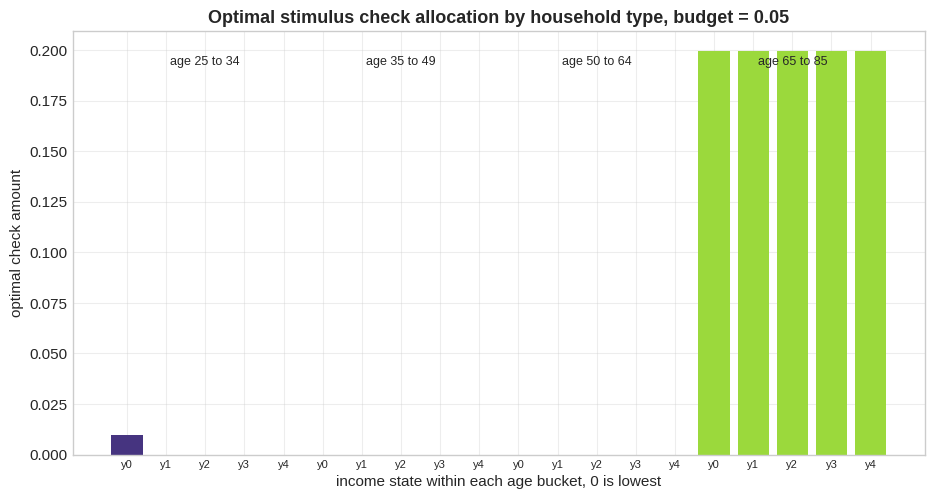

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
colors_age = plt.cm.viridis(np.linspace(0.15, 0.85, len(age_buckets)))
x_pos = np.arange(len(types))
bar_colors = [colors_age[i // n_income] for i in range(len(types))]
ax.bar(x_pos, optimal_alloc, color=bar_colors)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"y{i_y}" for (_, i_y) in types], fontsize=8)
for i, (a_lo, a_hi) in enumerate(age_buckets):
    ax.text(i * n_income + n_income / 2 - 0.5, ax.get_ylim()[1] * 0.92, f"age {a_lo} to {a_hi}",
            ha='center', fontsize=9)
ax.set_ylabel('optimal check amount')
ax.set_xlabel('income state within each age bucket, 0 is lowest')
ax.set_title('Optimal stimulus check allocation by household type, budget = 0.05')
plt.show()

## 8. Comparison to a Realistic Flat Payment Policy

Actual stimulus checks are not solved for as an optimal allocation problem. The 2020 CARES Act, for example, paid a flat amount per adult, with the payment phased out linearly above an income threshold and reduced to zero above a second, higher threshold. This section builds a stylized version of that kind of policy, calibrated to spend the same total budget as the optimal allocation above, and asks how much aggregate welfare is left on the table by not targeting.

The flat policy pays $c_0$ to any household with income below $y_1$, tapers linearly to zero between $y_1$ and $y_2$, and pays nothing above $y_2$, closely mirroring the structure of the real policy without attempting to match its exact dollar thresholds, which are not directly comparable to the normalized income units used in this model.

In [11]:
income_proxy = np.array([income_shock_grid[i_y] for (age_idx, i_y) in types])

def flat_phaseout_alloc(c0, y1, y2):
    return np.where(income_proxy <= y1, c0,
             np.where(income_proxy >= y2, 0.0, c0 * (y2 - income_proxy) / (y2 - y1)))

def flat_spend(c0, y1=0.9, y2=1.8):
    return np.sum(weights * flat_phaseout_alloc(c0, y1, y2))

# calibrate c0 so the flat policy spends exactly the same total budget as the optimal allocation
c0_lo, c0_hi = 0.0, 2.0
for _ in range(60):
    c0_mid = 0.5 * (c0_lo + c0_hi)
    if flat_spend(c0_mid) > budget:
        c0_hi = c0_mid
    else:
        c0_lo = c0_mid
c0_star = 0.5 * (c0_lo + c0_hi)
flat_alloc = flat_phaseout_alloc(c0_star, 0.9, 1.8)

optimal_welfare = sum(weights[i] * value_of_check(types[i][0], 0.0, types[i][1], optimal_alloc[i])
                       for i in range(len(types)))
flat_welfare = sum(weights[i] * value_of_check(types[i][0], 0.0, types[i][1], flat_alloc[i])
                    for i in range(len(types)))

print("flat policy base payment c0 =", round(c0_star, 4))
print("flat policy total spend =", round(flat_spend(c0_star), 5), " target budget =", budget)
print()
print("optimal allocation total welfare:", round(optimal_welfare, 5))
print("flat plus phaseout total welfare:", round(flat_welfare, 5))
print("welfare gain from optimal targeting:", round(optimal_welfare - flat_welfare, 5),
      f", or {100 * (optimal_welfare / flat_welfare - 1):.1f} percent higher, at the same total cost")

flat policy base payment c0 = 0.0663
flat policy total spend = 0.05  target budget = 0.05

optimal allocation total welfare: 0.20629
flat plus phaseout total welfare: 0.09739
welfare gain from optimal targeting: 0.1089 , or 111.8 percent higher, at the same total cost


Diagram: the two allocation rules side by side. The flat plus phaseout rule pays every household below the first income threshold the same amount, spreading the budget thinly across many types that, per the marginal value calculation above, do not actually need it as much as the very lowest income and oldest households do. The optimal rule concentrates the identical budget on fewer, higher marginal value types instead.

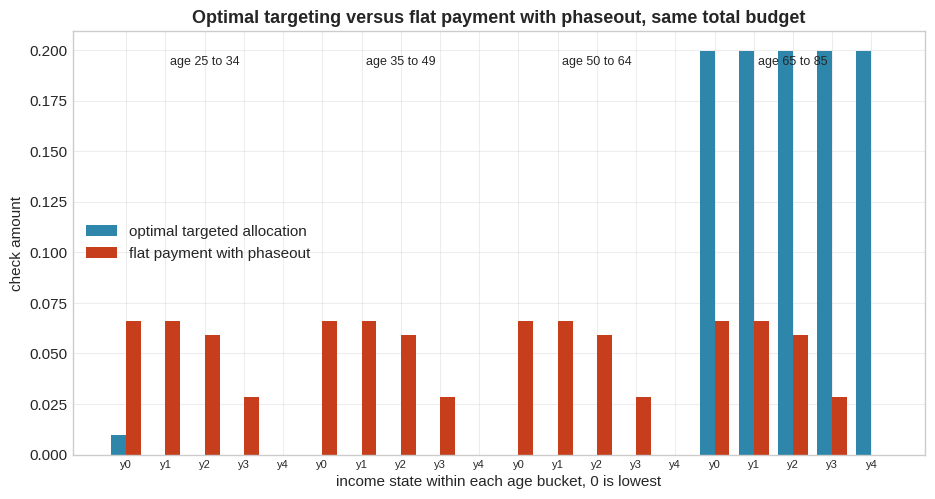

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
width = 0.38
x_pos = np.arange(len(types))
ax.bar(x_pos - width / 2, optimal_alloc, width, color='#2E86AB', label='optimal targeted allocation')
ax.bar(x_pos + width / 2, flat_alloc, width, color='#C73E1D', label='flat payment with phaseout')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"y{i_y}" for (_, i_y) in types], fontsize=8)
for i, (a_lo, a_hi) in enumerate(age_buckets):
    ax.text(i * n_income + n_income / 2 - 0.5, ax.get_ylim()[1] * 0.92, f"age {a_lo} to {a_hi}",
            ha='center', fontsize=9)
ax.set_ylabel('check amount')
ax.set_xlabel('income state within each age bucket, 0 is lowest')
ax.set_title('Optimal targeting versus flat payment with phaseout, same total budget')
ax.legend()
plt.show()